# DepthAnythingv2 Pipeline

In [1]:
import torch
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import open3d as o3d
import sys
sys.path.append("../")
from utils.imageSelector import select_equally_distributed_images

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Loading and viewing images

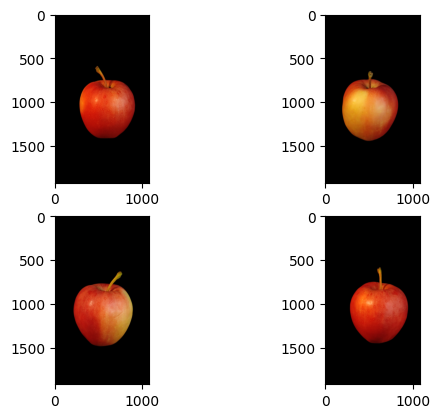

In [2]:
# Import images

input_dir = "../data/images"
image_paths = select_equally_distributed_images(input_dir, n = 5)[0:4]

# Load images and display them

images = [Image.open(path).convert("RGB") for path in image_paths]

f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(images[0])
axarr[0,1].imshow(images[1])
axarr[1,0].imshow(images[2])
axarr[1,1].imshow(images[3])


## Generating the Depth Images

In [ ]:
# Loading the model

model_path = "depth-anything/Depth-Anything-V2-Metric-Indoor-Large-hf"
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForDepthEstimation.from_pretrained(model_path).eval()


c:\Users\gusta\Documents\ProjetosDiversao\ReconstructionStudies\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gusta\.cache\huggingface\hub\models--depth-anything--Depth-Anything-V2-Metric-Indoor-Large-hf. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

In [4]:
# Generate depth maps

depth_maps = []
for image in images:
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth.squeeze().cpu().numpy()
    
    # Resize to match input resolution
    predicted_depth_resized = cv2.resize(predicted_depth, (image.width, image.height))
    
    depth_maps.append(predicted_depth_resized)

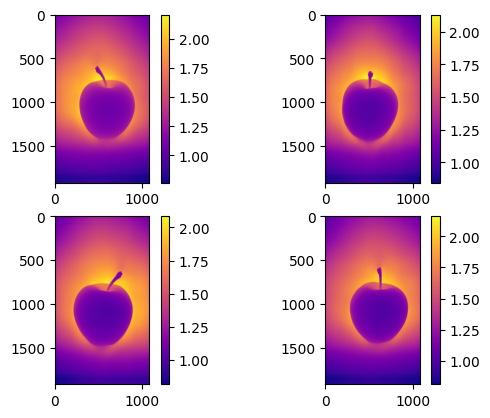

In [5]:
# Visualize the depth maps

f, axarr = plt.subplots(2,2)
im00 = axarr[0,0].imshow(depth_maps[0], cmap='plasma')
im01 = axarr[0,1].imshow(depth_maps[1], cmap='plasma')
im10 = axarr[1,0].imshow(depth_maps[2], cmap='plasma')
im11 = axarr[1,1].imshow(depth_maps[3], cmap='plasma')

f.colorbar(im00, ax=axarr[0,0])
f.colorbar(im01, ax=axarr[0,1])
f.colorbar(im10, ax=axarr[1,0])
f.colorbar(im11, ax=axarr[1,1])


## Helpers

In [19]:
def rotation_matrix_axis_angle(axis, angle):
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle)*K + (1 - np.cos(angle))*(K @ K)

In [21]:
def backproject_depth_to_points(depth, fx, fy, cx, cy):
    h, w = depth.shape
    jj, ii = np.meshgrid(np.arange(w), np.arange(h))   # ii = y, jj = x
    z = depth.astype(np.float32)
    mask = z > 1e-6
    x = (jj - cx) * z / fx
    y = (ii - cy) * z / fy
    pts = np.stack([x, y, z], axis=-1).reshape(-1,3)
    return pts, mask.reshape(-1)

## Convert to point clouds

In [6]:
# Setting camera parameters (Supposition)
""" fx = 1.73385664e+03  # focal length x (pixels)
fy = 1.76271719e+03  # focal length y (pixels) """
fx = 470.4  # focal length x (pixels)
fy = 470.4  # focal length y (pixels)

In [30]:
pcds = []
for k, (depth, color) in enumerate(zip(depth_maps, images)):  # depth_maps = metric depths
    pts, mask = backproject_depth_to_points(depth, fx, fy, cx, cy)
    pts = pts[mask]
    # optional color
    colors = np.array(color).reshape(-1,3)[mask] / 255.0

    # Keep only non-black (or non-near-black) points
    keep_mask = np.any(colors > 0.5, axis=1)
    filtered_points = pts[keep_mask]
    filtered_colors = colors[keep_mask]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(filtered_points)
    pcd.colors = o3d.utility.Vector3dVector(filtered_colors)
    
    pcd, ind = o3d.geometry.PointCloud.remove_statistical_outlier(
        pcd,
        nb_neighbors=20,
        std_ratio=2.0
    )

    o3d.visualization.draw_geometries([pcd])
    pcds.append(pcd)

## Estimate pivot (rotation center) from centroids

In [23]:
centroids = np.array([np.asarray(p.points).mean(axis=0) for p in pcds])
pivot = centroids.mean(axis=0)

In [26]:
axis = np.array([0.0, -1.0, 0.0])

## Align point cloud

In [31]:
aligned = []
for k, pcd in enumerate(pcds):
    R_k = rotation_matrix_axis_angle(axis, k * np.pi / 2)  # object rotated +k*90°
    pts = np.asarray(pcd.points)
    # row-vector form:
    pts_obj = (pts - pivot) @ R_k.T + pivot   # use R_k.T for inverse rotation
    out = o3d.geometry.PointCloud()
    out.points = o3d.utility.Vector3dVector(pts_obj)
    out.colors = pcd.colors
    aligned.append(out)

o3d.visualization.draw_geometries(aligned)

## ICP refinement + merge

In [34]:
for p in aligned: 
    p.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))

for i in range(1, len(aligned)):
    reg = o3d.pipelines.registration.registration_icp(
        aligned[i], aligned[0], 0.05, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane())
    aligned[i].transform(reg.transformation)

merged3 = o3d.geometry.PointCloud()
for pcd in aligned:
    merged3 += pcd
merged3 = merged3.voxel_down_sample(voxel_size=0.005)
merged3, _ = merged3.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.5)
o3d.visualization.draw_geometries([merged3])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
